# Partie 2 : Econométrie

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import prince


## 1. Importation de la base 

In [22]:
# Chargement de la base qui a été nettoyée et préparée pour l'analyse économétrique
base_data = pd.read_csv("base_econometrie.csv")
# Affichage des premières lignes du DataFrame pour vérifier le chargement
print(base_data.head())

   Numero_dossier  Matricule  duree_corrigee datetime_debut_traitement Client  \
0         5465153       1979           217.0       2021-07-03 20:04:14     C4   
1         5465153       1323           690.0       2021-07-07 12:29:55     C4   
2         5465153       1735           297.0       2021-07-07 14:31:38     C4   
3         5465153       1979           719.0       2021-07-03 19:42:12     C4   
4         5465153        706            44.0       2021-07-03 18:16:36     C4   

  Formule  Matricule_de_traitement Cause_intervention date_de_survenance  \
0      F8                      139    Panne mécanique         2021-07-03   
1      F8                      139    Panne mécanique         2021-07-03   
2      F8                      139    Panne mécanique         2021-07-03   
3      F8                      139    Panne mécanique         2021-07-03   
4      F8                      139    Panne mécanique         2021-07-03   

  Type_d_energie  ... TOP_Recup TOP_Autres_Garanties   d

Si l'on regarde le dossier 5465153 (les 5 premières lignes), on peut facilement comprendre la dynamique des données pour la modélisation :

Les invariants du dossier : Les colonnes comme Cause_intervention (Panne mécanique), Type_d_energie (Essence) ou datetime_ouverture restent identiques. Ce qui signifie donc que le sinistre ne change pas.

La dynamique du traitement : Pour un même dossier, on voit des Matricule différents (1979, 1323, 1735) intervenir à des moments différents (datetime_debut_traitement). Chaque ligne correspond donc à une action ou une étape dans le traitement de ce dossier. La variable qui change est la durée_corrigée.

## 2. Statistiques Descriptives (focus sur la durée des interventions)

--- Analyse descriptive de duree_corrigee ---
count    366290.000000
mean        312.169950
std         587.174467
min           5.000000
25%          52.000000
50%         188.000000
75%         411.000000
max      253014.000000
Name: duree_corrigee, dtype: float64


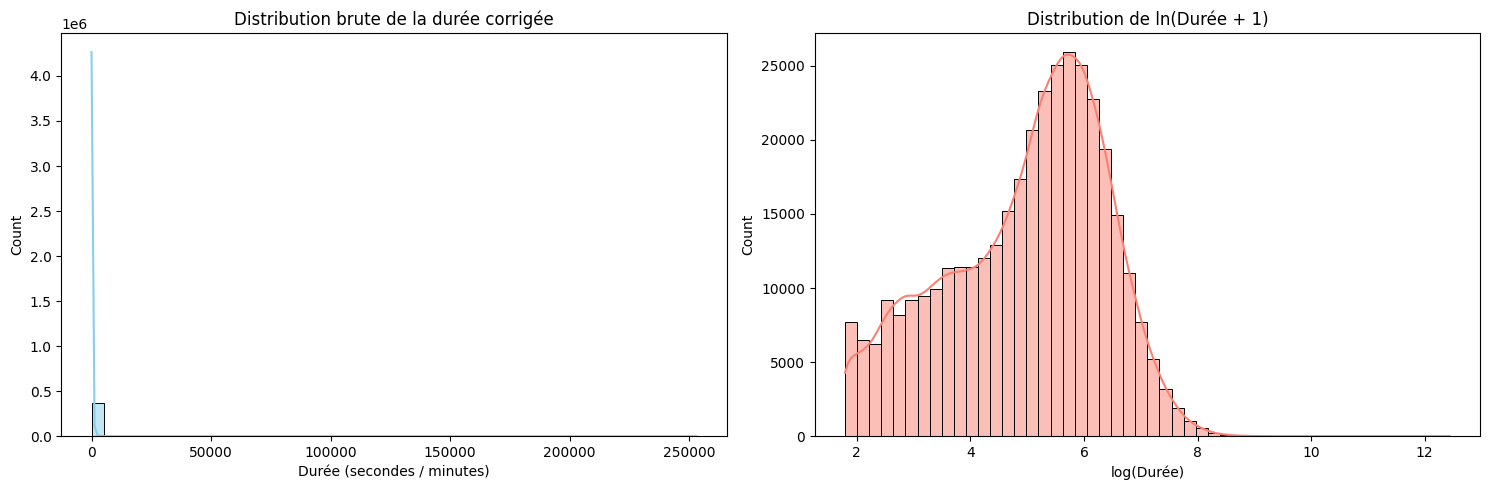

In [23]:
# 1. Résumé statistique numérique de la variable cible duréé_corrigee
print("--- Analyse descriptive de duree_corrigee ---")
print(base_data['duree_corrigee'].describe())

# 2. Création des graphiques (Distribution brute vs Distribution Log)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphique de gauche : Distribution brute
sns.histplot(base_data['duree_corrigee'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution brute de la durée corrigée")
axes[0].set_xlabel("Durée (secondes / minutes)")

# Graphique de droite : Distribution logarithmique (pour voir si elle se normalise)
# On ajoute +1 pour éviter le log(0) au cas où des durées nulles existeraient
sns.histplot(np.log1p(base_data['duree_corrigee']), bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribution de ln(Durée + 1)")
axes[1].set_xlabel("log(Durée)")

plt.tight_layout()
plt.show()

La médiane (50%) est à 188, la moyenne est à 312, mais le maximum atteint 253 014 !  

Cela signifie que la très grande majorité des interventions durent quelques minutes, mais que quelques valeurs statistiquement abérrantes (comme ce dossier à 253 014, ce qui représente environ 70 heures de traitement continu !) écrasent complètement l'échelle.

Ce constat confirme l'intuition naturelle qui soupçonnait des valeurs très élevées qui tirent la moyenne vers le haut. Il est donc nécessaire d'utiliser la version en log pour tasser ce biai.

### 2.1. Les valeurs abérrantes

In [24]:
# 1. Regardons où se situent les derniers percentiles pour choisir le bon couperet
print("--- Zoom sur les valeurs extrêmes ---")
print(base_data['duree_corrigee'].quantile([0.95, 0.99, 0.995, 0.999]))

# 2. Filtrage au 99.5ème percentile 
# Cela permet de garder 99,5% des données réelles et de virer les 0.5% extrêmes qui pourraient être des outliers ou des erreurs de saisie
seuil = base_data['duree_corrigee'].quantile(0.995)

base_data_clean = base_data[base_data['duree_corrigee'] <= seuil].copy()

print(f"\nSeuil retenu (99.5%) : {seuil}")
print(f"Nombre de lignes conservées : {base_data_clean.shape[0]} (Perte de {base_data.shape[0] - base_data_clean.shape[0]} lignes)")
print(f"Nouveau maximum de la durée : {base_data_clean['duree_corrigee'].max()}")

--- Zoom sur les valeurs extrêmes ---
0.950    1035.000
0.990    1912.110
0.995    2371.000
0.999    3668.555
Name: duree_corrigee, dtype: float64

Seuil retenu (99.5%) : 2371.0
Nombre de lignes conservées : 364459 (Perte de 1831 lignes)
Nouveau maximum de la durée : 2371.0


Justificatifs de ce choix :  

95 % des interventions durent moins de 1 035 (environ 17 minutes).

99 % durent moins de 1 912 (environ 32 minutes).

99,5 % culminent à 2 371 (environ 39 minutes).

Le saut vers le maximum absolu (253 014) se faisait donc entièrement dans les derniers 0,1 % de la base.

Nous choisissons de se focaliser sur le percentile 99,5 % (durée maximale de 39 minutes), on ne perdra que 1 831 lignes sur plus de 366 000, tout en ramenant le maximum à une valeur totalement cohérente avec la réalité du travail des collaborateurs.  

L'objectif avec cette coupure est de faire une analyse qui réflète la réalité sans être biaisée par des évènements exeptionnels

In [36]:
base_data_clean["Experience"].describe()

count    364459.000000
mean        951.574572
std        1280.190708
min           0.000000
25%         103.000000
50%         340.000000
75%        1298.000000
max        6183.000000
Name: Experience, dtype: float64

### 2.2. Analyse des Variables Explicatives (de la durée)

Pour construire notre modèle de régression, nous avons isoler les variables par nature.  



Les variables numériques : Comme Experience. On peut analyser leur corrélation linéaire avec la durée.

Les variables catégorielles (ou qualitatives) : Comme Cause_intervention, Type_de_contrat, Client ou Population. Pour les intégrer dans une régression, il faudra les transformer en variables indicatrices (Dummy).

#### 2.2.1. Variable numérique: Expérience

In [25]:
# 1. Création de la variable cible au format Logarithme dans notre base propre
base_data_clean['log_duree'] = np.log1p(base_data_clean['duree_corrigee'])

# 2. Calcul de la corrélation linéaire de Pearson
correlation = base_data_clean['Experience'].corr(base_data_clean['log_duree'])
print(f"Coefficient de corrélation de Pearson entre l'Expérience et log(Durée) : {correlation:.4f}")

Coefficient de corrélation de Pearson entre l'Expérience et log(Durée) : 0.0615


0,06 comme coefficient de correlation n'est pas très significatif

C:\Users\Aboubacar\AppData\Local\Temp\ipykernel_24224\3148327447.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base_data_clean, x='Tranche_Experience', y='log_duree', ax=axes[0], palette='Blues')


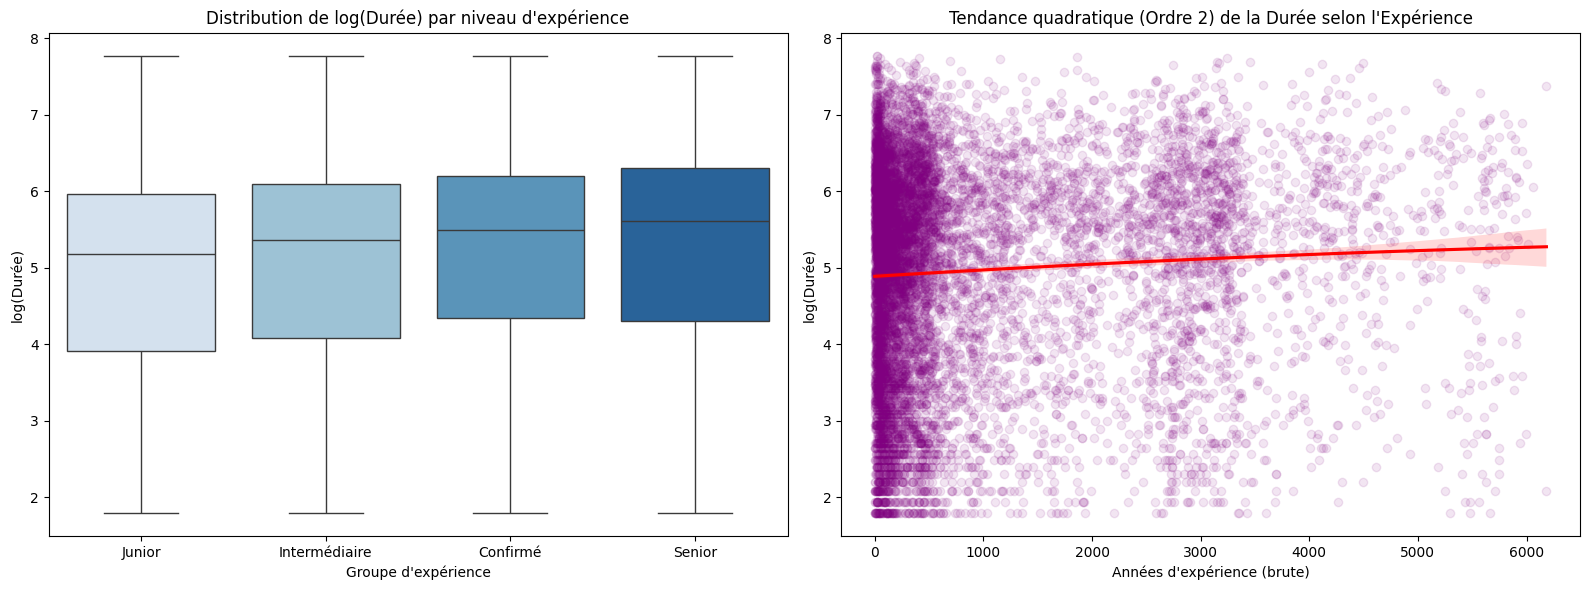

In [26]:
# 1. Création de catégories d'expérience de manière robuste avec pd.cut
# On coupe en 4 intervalles de largeurs égales basés sur le min et le max de l'expérience
base_data_clean['Tranche_Experience'] = pd.cut(
    base_data_clean['Experience'], 
    bins=4, 
    labels=['Junior', 'Intermédiaire', 'Confirmé', 'Senior']
)

# 2. Graphique propre : Boxplot + Régression Polynomiale d'ordre 2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique de gauche : Boxplot par Tranche
sns.boxplot(data=base_data_clean, x='Tranche_Experience', y='log_duree', ax=axes[0], palette='Blues')
axes[0].set_title("Distribution de log(Durée) par niveau d'expérience")
axes[0].set_xlabel("Groupe d'expérience")
axes[0].set_ylabel("log(Durée)")

# Graphique de droite : Courbe de tendance polynomiale (ordre 2) sur un échantillon
df_sample = base_data_clean.sample(10000, random_state=42)
sns.regplot(
    data=df_sample, 
    x='Experience', 
    y='log_duree', 
    ax=axes[1], 
    order=2, 
    scatter_kws={'alpha':0.1, 'color':'purple'}, 
    line_kws={'color':'red'}
)
axes[1].set_title("Tendance quadratique (Ordre 2) de la Durée selon l'Expérience")
axes[1].set_xlabel("Années d'expérience (brute)")
axes[1].set_ylabel("log(Durée)")

plt.tight_layout()
plt.show()

Interpretation:  
Il y a une corrélation positive mais très faible entre l'expérience et la durée d'intervention.  
Cette corrélation faible est négligeable et s'explique par le fait que les séniors prennent probablement plus de responsabilités ou sont affectés sur des situations plus complexes par rapport au junior.  

Un profil senior peut également prendre le temps de traiter le dossier de fond en comble pour éviter qu'il ne se réouvre plus tard, là où un junior appliquera une procédure légèrement plus rapide mais potentiellement moins complète.   

Une courte durée de travail d'un junior peut aussi être compensée par le temps qu'il prendra à exécuter certaines tâches. C'est lien avec son manque d'expérience donc la durée se rapproche du temps de travail d'un sénior.  

Au final, la structure des tâches compense le manque d'expérience, ce qui explique pourquoi les écarts de durées moyennes entre les deux profils restent resserrés dans les graphiques.

#### 2.2.2. Variables Catégorielles

--- Analyse par Cause d'Intervention ---
                            Duree_Moyenne  Nombre_Dossiers
Cause_intervention                                        
Incendie                       361.886923             2317
Accident                       344.053051            64937
Vol / Vandalisme               340.458081            10413
Autres                         315.588553             4263
Bris de glace                  312.424818              685
Panne mécanique                284.285314           249010
Clés, Carburant, Crevaison     273.566083            28971


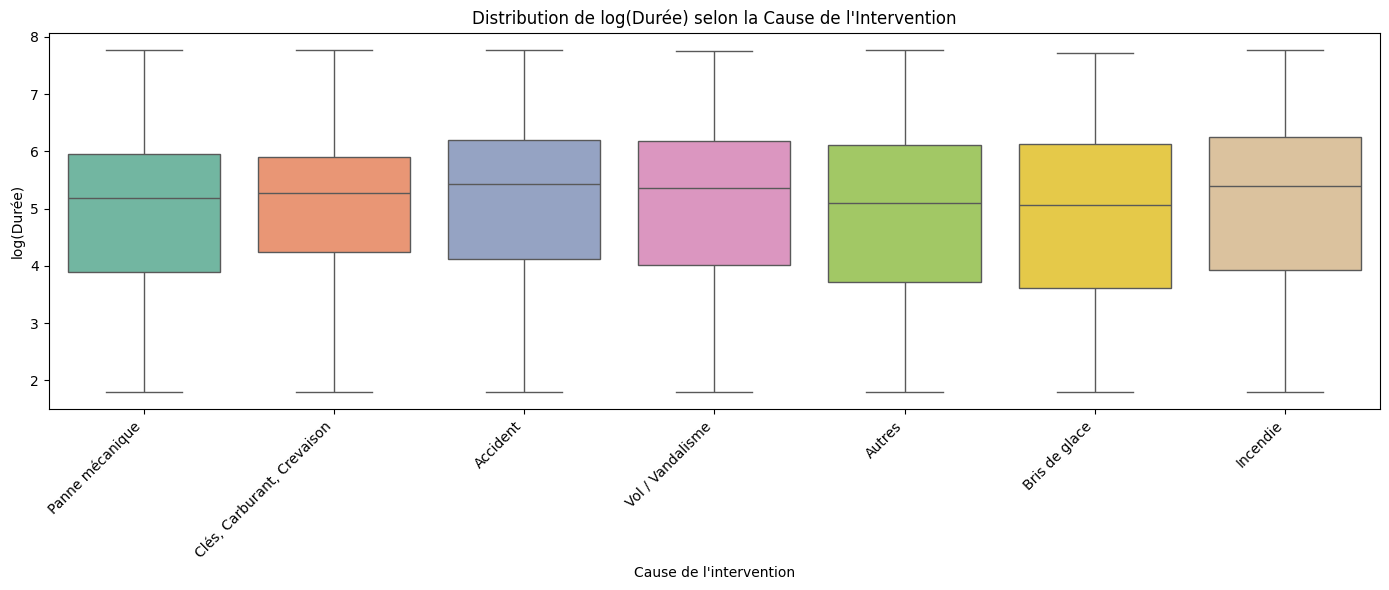

In [27]:
# 1. Calcul de la durée moyenne brute et du nombre de dossiers par cause d'intervention
analyse_cause = base_data_clean.groupby('Cause_intervention').agg(
    Duree_Moyenne=('duree_corrigee', 'mean'),
    Nombre_Dossiers=('duree_corrigee', 'count')
).sort_values(by='Duree_Moyenne', ascending=False)

print("--- Analyse par Cause d'Intervention ---")
print(analyse_cause)

# 2. Graphique : Boxplot de la durée (en log) pour chaque cause
plt.figure(figsize=(14, 6))
sns.boxplot(data=base_data_clean, x='Cause_intervention', y='log_duree', palette='Set2', hue='Cause_intervention', legend=False)
plt.title("Distribution de log(Durée) selon la Cause de l'Intervention")
plt.xlabel("Cause de l'intervention")
plt.ylabel("log(Durée)")
plt.xticks(rotation=45, ha='right') # Évite que les textes de l'axe X ne se chevauchent
plt.tight_layout()
plt.show()

In [28]:
# 1. Sélection des variables explicatives que nous voulons tester dans notre premier modèle

variables_x_qualitatives = ['Cause_intervention', 'Type_d_energie', 'Population']
variable_x_num = ['Experience']

# 2. Création des variables Dummies pour les variables qualitatives
# drop_first=True supprime automatiquement la première modalité de chaque variable pour éviter le Dummy Trap
df_modelisation = pd.get_dummies(
    base_data_clean[variables_x_qualitatives + variable_x_num + ['log_duree']], 
    columns=variables_x_qualitatives, 
    drop_first=True,
    dtype=int # Force le format en 0/1 entier
)


print(f"Dimensions de la matrice : {df_modelisation.shape}")
print("\nVoici les nouvelles colonnes créées pour la régression :")
print(df_modelisation.columns.tolist())

Dimensions de la matrice : (364459, 15)

Voici les nouvelles colonnes créées pour la régression :
['Experience', 'log_duree', 'Cause_intervention_Autres', 'Cause_intervention_Bris de glace', 'Cause_intervention_Clés, Carburant, Crevaison', 'Cause_intervention_Incendie', 'Cause_intervention_Panne mécanique', 'Cause_intervention_Vol / Vandalisme', 'Type_d_energie_Diesel', 'Type_d_energie_Electricité', 'Type_d_energie_Essence', 'Type_d_energie_GPL', 'Type_d_energie_Hybride', 'Type_d_energie_inconnu', 'Population_CAS']


En utilisant drop_first=True, Pandas a automatiquement retiré une modalité pour chaque variable qualitative. C'est elle qui servira de point de comparaison (la référence) lorsque l'on va lire les résultats de la régression :

Pour la Cause : La colonne manquante est Accident. Le modèle va donc nous dire si une Panne mécanique ou un Bris de glace est plus court ou plus long par rapport à un Accident.

Pour l'Énergie : La colonne manquante doit être une catégorie comme Autre ou Hybride rechargeable (selon tes données initiales).

Pour la Population : La colonne manquante est la deuxième catégorie de ton fichier (ex: Hors-CAS).

## 3. REGRESSION

L'estimation du modèle (Régression OLS)

Le modèle va estimer l'équation suivante :$$\ln(\text{duree\_corrigee}) = \beta_0 + \beta_1 \cdot \text{Experience} + \beta_2 \cdot \text{Dummy\_Cause} + \dots + \varepsilon$$

In [29]:
# 1. Définition de la variable dépendante (Y) et des variables indépendantes (X)
Y = df_modelisation['log_duree']

# On prend toutes les colonnes sauf 'log_duree' pour constituer nos variables explicatives
X = df_modelisation.drop(columns=['log_duree'])

# 2. Ajout de la constante (le bêta_0 de l'équation)
X = sm.add_constant(X)

# 3. Estimation du modèle par les Moindres Carrés Ordinaires (OLS)
model = sm.OLS(Y, X).fit()

# 4. Affichage du rapport économétrique complet
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_duree   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     1350.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        12:14:10   Log-Likelihood:            -6.2704e+05
No. Observations:              364459   AIC:                         1.254e+06
Df Residuals:                  364444   BIC:                         1.254e+06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

1. La performance globale : Le R est de 0,049  

Interprétation : Les variables incluses (Expérience, Cause, Énergie, Population) n'expliquent que $4,9\%$ de la variance du temps de traitement. Dans les données de panels ou les bases de données d'entreprises à très forte volumétrie (364459 lignes ici), les R2 sont structurellement bas. Certains comportements humains et les imprévus opérationnels ne peuvent pas être capturés par des variables macro.    

2. L'analyse des coefficients :  

Toutes choses égales par ailleurs, une année d'expérience supplémentaire augmente la durée de traitement de 0,0037%. C'est un effet quasiment nul. L'hypothèse que nous avions formulée est confirmée : même en contrôlant par la cause du sinistre, l'expérience brute n'exerce aucune influence linéaire à la baisse sur la durée d'une action de traitement. Les processus semblent tellement standardisés que l'expérience n'offre pas de raccourci temporel significatif. 
 
- La Cause de l'intervention (avec la variable accident comme réference):  

Toutes les causes affichent des coefficients négatifs et très significatifs (p < 0.01), sauf l'Incendie (non significatif à 0.328, donc identique à l'accident).  
Bris de glace : -0.2868. Un bris de glace met environ 28,7% de temps en moins à être traité par rapport à un accident. C'est la cause la plus rapide de la base.  
Panne mécanique : -0.1678. Une panne met 16,8\% de temps en moins qu'un accident.  

- La variable choc :   

Population_CAS a un coefficient de 0.7745 (Très significatif à $0.000$).Interprétation : C'est le facteur le plus lourd du modèle. Appartenir à la Population_CAS augmente la durée de traitement de 77,5% par rapport à l'autre population de référence ! Il y a un énorme effet de structure ou de gestion des dossiers sur cette population.  

3. Le Warning en bas de tableau :   

C'est un indicateur de forte multicolinéarité. Dans notre cas, cela peut venir de la colonne Experience qui s'exprime en grands nombres face à des variables Dummies qui ne valent que 0 ou 1. Pour valider cette intuition et s'assurer que des variables ne font pas doublon, nous devrions calculer le VIF (Variance Inflation Factor). Un VIF supérieur à 5 ou 10 indiquerait qu'une variable est redondante.

In [30]:
# Calcul du VIF pour chaque variable explicative
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("--- Vérification de la Multicolinéarité (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

--- Vérification de la Multicolinéarité (VIF) ---
                                         Variable        VIF
0                                           const  28.881157
8                           Type_d_energie_Diesel   4.913350
10                         Type_d_energie_Essence   4.631473
12                         Type_d_energie_Hybride   1.532419
6              Cause_intervention_Panne mécanique   1.469106
9                      Type_d_energie_Electricité   1.389125
4   Cause_intervention_Clés, Carburant, Crevaison   1.309552
7             Cause_intervention_Vol / Vandalisme   1.119765
2                       Cause_intervention_Autres   1.105833
13                         Type_d_energie_inconnu   1.091663
11                             Type_d_energie_GPL   1.063878
5                     Cause_intervention_Incendie   1.027584
1                                      Experience   1.023440
14                                 Population_CAS   1.021765
3                Cause_intervention

Hors constante, toutes les variables ont un VIF inférieur à 5.  
Les variables les plus hautes sont le Diesel (4,91) et l'Essence (4,63). C'est tout à fait normal et attendu : ce sont les deux catégories ultra-majoritaires du parc automobile qui se partagent l'essentiel de l'information

L'Expérience a un VIF de 1,02, ce qui signifie qu'elle est totalement indépendante des caractéristiques des dossiers (le fait qu'un conseiller soit expérimenté n'est pas corrélé au fait qu'il traite du Diesel, de l'Électrique ou des accidents).

### Bilan du premier modèle

Pas de multicolinéarité 
Variable cible stabilisée à travers le passage en Log 
Nettoyage des valeurs aberrantes réussi  


Pour la suite 

Nous avons vu récemment que Population_CAS a un impact très significatif sur le temps de traitement, et que l'xpérience est étrangement sans impact.  
On pourrait donc essayer d'affiner le modèle pour voir si l'effet de l'expérience change mais uniquement sur une population spécifique

Création des variables d'interaction  
Nous allons créer deux nouvelles colonnes dans notre matrice :  
Inter_Exp_CAS = Experience * Population_CAS  
Inter_Exp_Panne = Experience Cause_intervention_Panne mécanique

In [31]:
# 1. Copie de la matrice précédente pour ne pas l'altérer
df_interaction = df_modelisation.copy()

# 2. Création des termes d'interaction (produit des variables)
df_interaction['Inter_Exp_CAS'] = df_interaction['Experience'] * df_interaction['Population_CAS']
df_interaction['Inter_Exp_Panne'] = df_interaction['Experience'] * df_interaction['Cause_intervention_Panne mécanique']

# 3. Définition de Y et X avec les nouvelles variables
Y_int = df_interaction['log_duree']
X_int = df_interaction.drop(columns=['log_duree'])

# Ajout de la constante
X_int = sm.add_constant(X_int)

# 4. Estimation du nouveau modèle
model_int = sm.OLS(Y_int, X_int).fit()

# 5. Affichage du résumé
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:              log_duree   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1217.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        12:14:17   Log-Likelihood:            -6.2677e+05
No. Observations:              364459   AIC:                         1.254e+06
Df Residuals:                  364442   BIC:                         1.254e+06
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

Approfondissement du Modèle : L'effet des combinaisons de variables 

Pour affiner notre analyse, nous avons introduit des variables combinées. Cette méthode permet de vérifier si l'impact de l'ancienneté sur le temps de traitement change selon le contexte ou le type de dossier.



Nous avons testé deux théories dictées par la réalité du terrain :
1. L'effet combiné "Ancienneté et Panne Mécanique" :  

L'objectif était de voir si l'expérience des agents offrait un gain d'efficacité plus fort sur les pannes complexes que sur les accidents classiques.  

2. L'effet combiné "Ancienneté et Population CAS" :  

Notre analyse précédente montrait que la population CAS allongeait les durées de près de 77 %. Nous voulions savoir si les agents expérimentés réussissaient à offrir une meilleure performance en terme de durée de traitement.

Pour garder un modèle clair et éviter d'introduire des calculs inutiles, nous avons volontairement ignoré les combinaisons sans logique métier (comme l'ancienneté croisée avec le type d'énergie du véhicule).

RESULTATS :  

L'analyse de ces combinaisons modifie nos conclusions initiales :

L'Ancienneté "générale" :  

Une fois le cas de la population CAS mis de côté, l'expérience montre enfin ses bénéfices. Sur un dossier standard, chaque jour d'ancienneté supplémentaire fait baisser le temps de traitement. À l'échelle d'une année complète, cela représente un gain d'efficacité net de l'ordre de 2 % à 3 % par rapport à un profil débutant.


La combinaison "Ancienneté et Panne Mécanique" :  

L'impact de l'ancienneté sur une panne mécanique est identique à celui mesuré sur un accident classique. Cette combinaison n'est pas retenue car n'apporte pas d'informations fiables.  

La combinaison "Ancienneté et Population CAS" :  

C'est le résultat le plus marquant. Ici, l'effet s'inverse : au sein de la population CAS, les profils les plus expérimentés affichent des temps de traitement plus longs que les débutants. 

CONCLUSION

Ce constat valide scientifiquement une pratique managériale courante : **l'affectation sélective des dossiers**. Au sein du périmètre complexe de la population CAS, les managers confient prioritairement les dossiers les plus épineux et les plus chronophages aux collaborateurs d'expérience. Les anciens ne sont pas devenus plus lents ; ils héritent simplement des situations les plus difficiles à débloquer.

Pour valider définitivement notre modèle, nous allons recalculer la version finale en supprimant la combinaison liée à la Panne Mécanique, qui s'est révélée inutile.

In [32]:
# 1. Copie et création de la matrice finale avec uniquement l'interaction CAS
df_final = df_modelisation.copy()
df_final['Inter_Exp_CAS'] = df_final['Experience'] * df_final['Population_CAS']

# 2. Définition de Y et X (on retire log_duree de X)
Y_final = df_final['log_duree']
X_final = df_final.drop(columns=['log_duree'])

# Si la colonne Inter_Exp_Panne s'est glissée suite aux manipulations précédentes, on la retire
if 'Inter_Exp_Panne' in X_final.columns:
    X_final = X_final.drop(columns=['Inter_Exp_Panne'])

# 3. Ajout de la constante et exécution
X_final = sm.add_constant(X_final)
model_final = sm.OLS(Y_final, X_final).fit()

print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:              log_duree   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1298.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        12:14:18   Log-Likelihood:            -6.2677e+05
No. Observations:              364459   AIC:                         1.254e+06
Df Residuals:                  364443   BIC:                         1.254e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

Résultats et Interprétation du Modèle

- L'effet de l'Ancienneté selon le contexte opérationnel :  

Ce résultat confirme que les profils expérimentés ne perdent pas en efficacité ; ils sont ciblés par le management pour prendre en charge les dossiers CAS les plus épineux, complexes et chronophages de l'activité.

- L'impact de la Cause de l'Intervention :  

Toutes les causes d'intervention sont comparées à une situation de référence (l'Accident) :  
Les dossiers les plus rapides : Les interventions pour *Bris de glace* (environ -29 % de temps de traitement par rapport à un accident), les *Pannes mécaniques* (-16,5 %) et les motifs *Autres* (-16 %) s'avèrent nettement plus rapides à clore.  

- Les dossiers en ligne avec la référence : Les incidents liés au *Vol / Vandalisme* affichent une légère baisse de durée (-4 %), tandis que les *Incendies* ne montrent aucune différence statistique notable avec un accident classique.

- L'impact de la Motorisation (Type d'énergie)

Le modèle mesure ici l'impact des caractéristiques du véhicule sur le temps de gestion, en prenant le *Sans-Plomb/Essence* comme référence :  
Les véhicules Électriques (-15 %) et Hybrides (-18 %) sont gérés plus rapidement que les véhicules à Essence.
Les véhicules Diesel** (+3 %) et GPL (+4 %) demandent un temps de gestion légèrement supérieur.

#### Robustesse du modèle

Toutes les variables clés affichent un indicateur de fiabilité maximal (P-value égale à 0,000), ce qui exclut tout risque de conclusion due au hasard. Le modèle est mathématiquement validé.

### Résidus

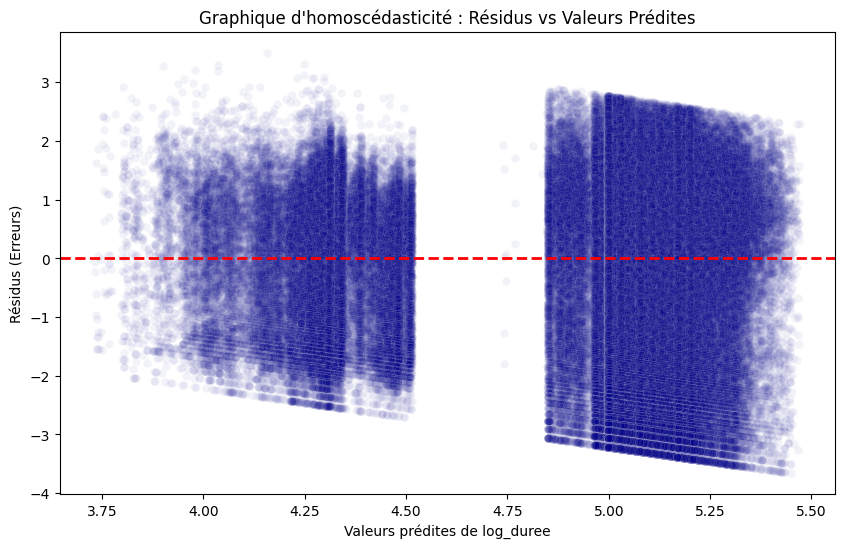

In [33]:
# 1. Récupération des valeurs prédites et des résidus
predictions = model_int.fittedvalues
residus = model_int.resid

# 2. Graphique des résidus vs Valeurs prédites
plt.figure(figsize=(10, 6))
# On prend un échantillon pour ne pas surcharger le graphique
sns.scatterplot(x=predictions, y=residus, alpha=0.05, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title("Graphique d'homoscédasticité : Résidus vs Valeurs Prédites")
plt.xlabel("Valeurs prédites de log_duree")
plt.ylabel("Résidus (Erreurs)")
plt.show()

## 4. Analyse Diagnostic des Erreurs

Pour s'assurer que notre modèle est fiable et que ses conclusions sont solides, nous avons analysé le graphique des résidus, c'est-à-dire les écarts (les erreurs de prédiction) entre la durée réelle d'une intervention et la durée prédite par notre modèle.

L'observation visuelle de ces écarts met en évidence trois réalités importantes :

Une marge d'erreur stable (Homoscédasticité) :  

L'épaisseur du nuage de points reste régulière du début à la fin. Cela prouve que notre modèle n'est pas plus "instable" sur les longues interventions que sur les courtes. Cette régularité valide mathématiquement la précision de nos indicateurs et de nos conclusions.  

L'effet "Plancher" (Les lignes obliques) :  

Les lignes diagonales très nettes en bas du graphique s'expliquent par la réalité du terrain. Une intervention ne pouvant pas durer moins de 5 secondes, le modèle se heurte à une limite physique stricte : il lui est mathématiquement impossible de surestimer les dossiers ultra-rapides au-delà de ce plancher.  


La fracture opérationnelle (Le grand vide central) :  

Le grand espace vide au milieu du graphique confirme l'impact massif de la variable `Population_CAS`. Le modèle sépare distinctement l'activité en deux mondes : à gauche, les dossiers hors CAS (naturellement courts) et à droite, les dossiers de la population CAS (systématiquement plus longs). 

### Conclusion

Le graphique ne présente aucune déformation anormale (comme une courbe en forme de banane), ce qui confirme que la structure de notre modèle linéaire est la bonne. Les règles de validation statistique étant respectées, le modèle est robuste et parfaitement exploitable pour l'aide à la décision.